# Phone GPS Logging Analysis

**Author:** Jonah Lee

**Date:** 2026-04-02

**Relevant Links:**
- https://ubcsolar26.monday.com/boards/9565353662/pulses/9773051025/posts/5062100496

## Imports

Import any packages or dependencies for this project.
Uncomment or delete these lines as needed, and add other dependencies

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import folium
from pathlib import Path
import os

# Aesthetics
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.figsize": (12, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("All imports OK")

All imports OK


## Data Acquisition

Obtain the data relevant to this analysis. Load data from saved files, or query it directly.

In [8]:
data_path = Path(os.getcwd()) / "data" / "april_2_testing" / "20260402.csv"

df = pd.read_csv(data_path)

# Parse time and set as index
df["time"] = pd.to_datetime(df["time"], utc=True)
df = df.set_index("time").sort_index()

# Convert speed from m/s to km/h
df["speed_kmh"] = df["speed"] * 3.6

# Drop columns that are essentially empty
threshold = 0.05  # keep columns with >5% non-null values
df = df.dropna(axis=1, thresh=int(len(df) * threshold))

# Drop remaining low-value columns
drop_cols = [c for c in ["annotation", "activity", "dgpsid", "ageofdgpsdata", "geoidheight"] if c in df.columns]
df = df.drop(columns=drop_cols)

# Sanity check
duration = df.index[-1] - df.index[0]
print(f"Rows:        {len(df):,}")
print(f"Duration:    {duration}")
print(f"Time range:  {df.index[0]}  →  {df.index[-1]}")
print(f"Providers:   {df['provider'].value_counts().to_dict()}")
print(f"Speed range: {df['speed_kmh'].min():.1f} – {df['speed_kmh'].max():.1f} km/h")
print(f"\nAccuracy (m):")
print(df["accuracy"].describe().round(2))
print(f"\nRemaining columns:\n{list(df.columns)}")

Rows:        12,977
Duration:    0 days 07:38:38.295000
Time range:  2026-04-02 15:37:00.705000+00:00  →  2026-04-02 23:15:39+00:00
Providers:   {'gps': 12311, 'network': 666}
Speed range: 0.0 – 65.0 km/h

Accuracy (m):
count    12977.00
mean         5.26
std          8.02
min          0.90
25%          1.30
50%          1.40
75%         11.30
max         39.53
Name: accuracy, dtype: float64

Remaining columns:
['lat', 'lon', 'elevation', 'accuracy', 'bearing', 'speed', 'satellites', 'provider', 'hdop', 'vdop', 'pdop', 'battery', 'timestamp_ms', 'time_offset', 'distance', 'starttimestamp_ms', 'profile_name', 'battery_charging', 'speed_kmh']


## Analysis

Compute the desired results and present them. Take advantage of Markdown cells to guide the reader through your derivation process.

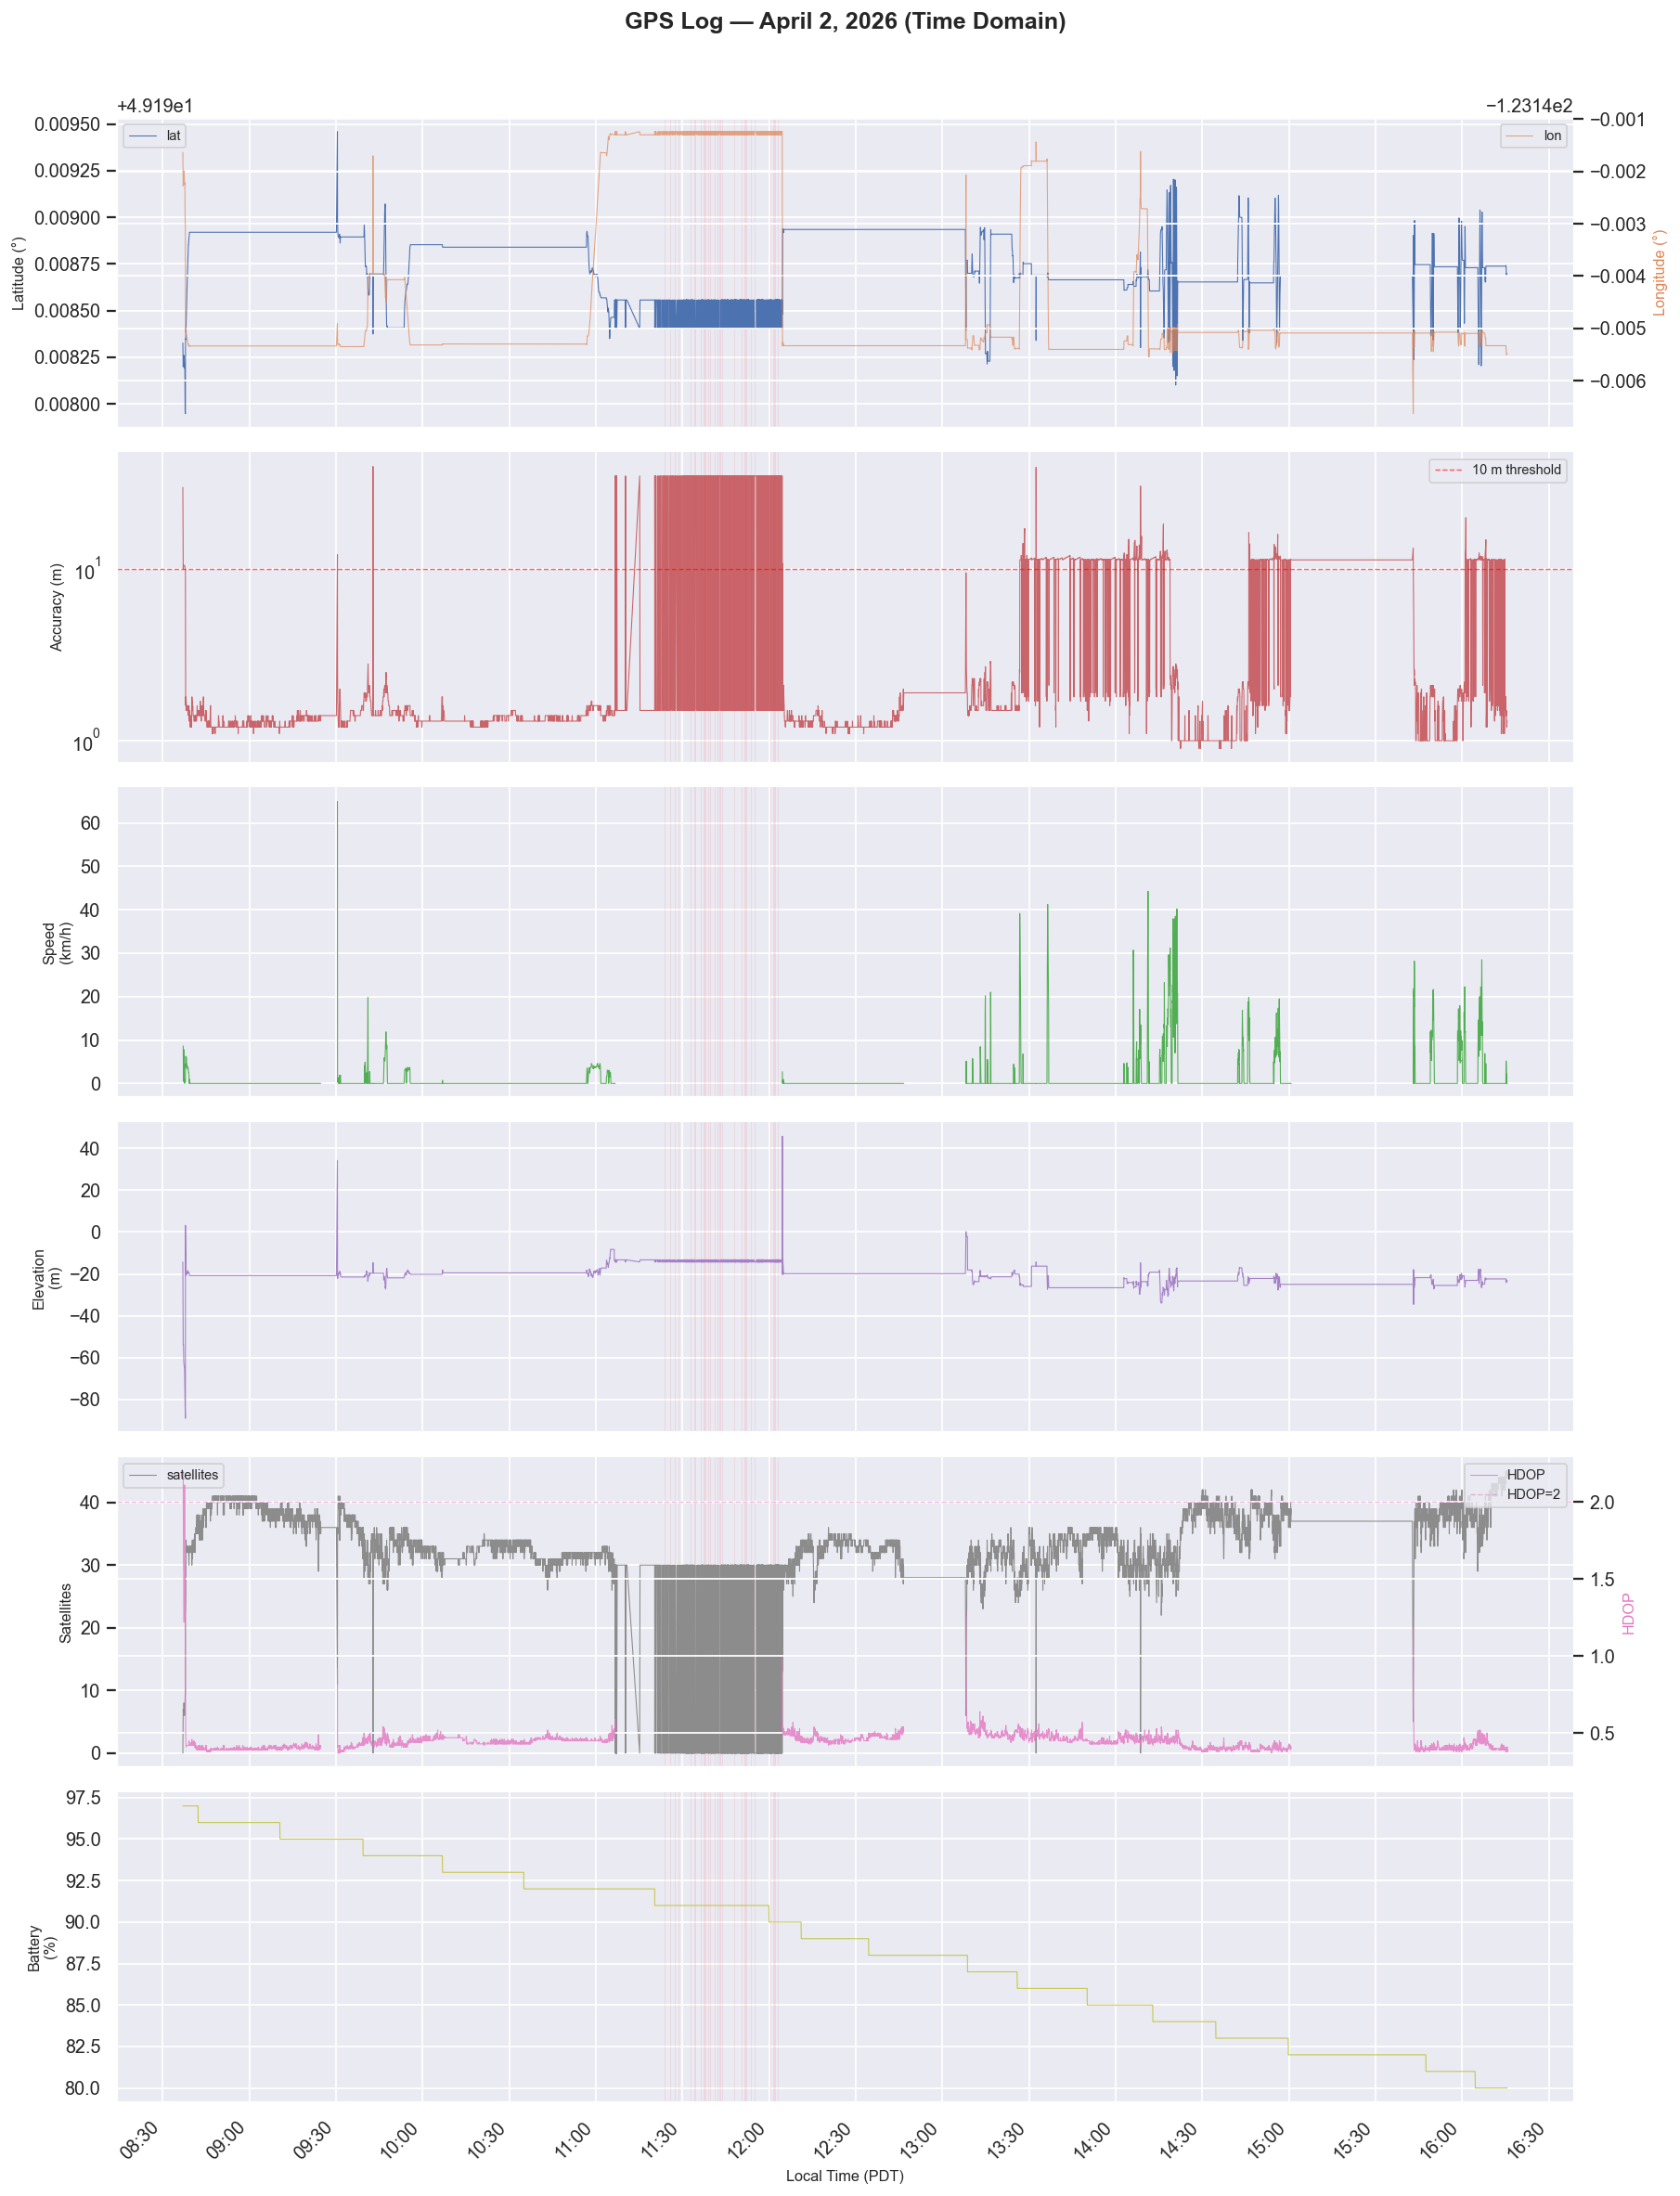

In [9]:
fig, axes = plt.subplots(6, 1, figsize=(14, 18), sharex=True)
fig.suptitle("GPS Log — April 2, 2026 (Time Domain)", fontsize=14, fontweight="bold", y=1.01)

# Use local time for readability
time = df.index.tz_convert("America/Vancouver")

def plot(ax, y, label, color, unit=None, hline=None):
    ax.plot(time, df[y], lw=0.6, alpha=0.8, color=color)
    ax.set_ylabel(f"{label}\n({unit})" if unit else label, fontsize=9)
    if hline is not None:
        ax.axhline(hline, color="red", lw=0.8, ls="--", alpha=0.6)
    ax.yaxis.set_label_position("left")

# Lat / Lon
axes[0].plot(time, df["lat"], lw=0.6, color="#4C72B0", label="lat")
axes[0].set_ylabel("Latitude (°)", fontsize=9)
ax0r = axes[0].twinx()
ax0r.plot(time, df["lon"], lw=0.6, color="#DD8452", alpha=0.7, label="lon")
ax0r.set_ylabel("Longitude (°)", fontsize=9, color="#DD8452")
axes[0].legend(loc="upper left", fontsize=8)
ax0r.legend(loc="upper right", fontsize=8)

# Accuracy — log scale helps show the bimodal distribution
axes[1].plot(time, df["accuracy"], lw=0.6, color="#c44e52", alpha=0.85)
axes[1].set_ylabel("Accuracy (m)", fontsize=9)
axes[1].set_yscale("log")
axes[1].axhline(10, color="red", lw=0.8, ls="--", alpha=0.6, label="10 m threshold")
axes[1].legend(fontsize=8)

# Speed
plot(axes[2], "speed_kmh", "Speed", "#2ca02c", unit="km/h")

# Elevation
plot(axes[3], "elevation", "Elevation", "#9467bd", unit="m")

# Satellites + HDOP on twin axes
axes[4].plot(time, df["satellites"], lw=0.6, color="#8c8c8c", label="satellites")
axes[4].set_ylabel("Satellites", fontsize=9)
ax4r = axes[4].twinx()
ax4r.plot(time, df["hdop"], lw=0.6, color="#e377c2", alpha=0.8, label="HDOP")
ax4r.set_ylabel("HDOP", fontsize=9, color="#e377c2")
ax4r.axhline(2.0, color="#e377c2", lw=0.8, ls="--", alpha=0.5, label="HDOP=2")
axes[4].legend(loc="upper left", fontsize=8)
ax4r.legend(loc="upper right", fontsize=8)

# Battery
plot(axes[5], "battery", "Battery", "#bcbd22", unit="%")

# X axis formatting
axes[5].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz="America/Vancouver"))
axes[5].xaxis.set_major_locator(mdates.MinuteLocator(byminute=range(0, 60, 30)))
plt.setp(axes[5].xaxis.get_majorticklabels(), rotation=45, ha="right")
axes[5].set_xlabel("Local Time (PDT)", fontsize=9)

# Provider shading — shade network fixes red
network_mask = df["provider"] == "network"
for ax in axes:
    for idx in df.index[network_mask]:
        t = idx.tz_convert("America/Vancouver")
        ax.axvspan(t, t + pd.Timedelta(seconds=1), color="red", alpha=0.08, lw=0)

fig.tight_layout()
plt.savefig("time_domain.png", dpi=150, bbox_inches="tight")
plt.show()

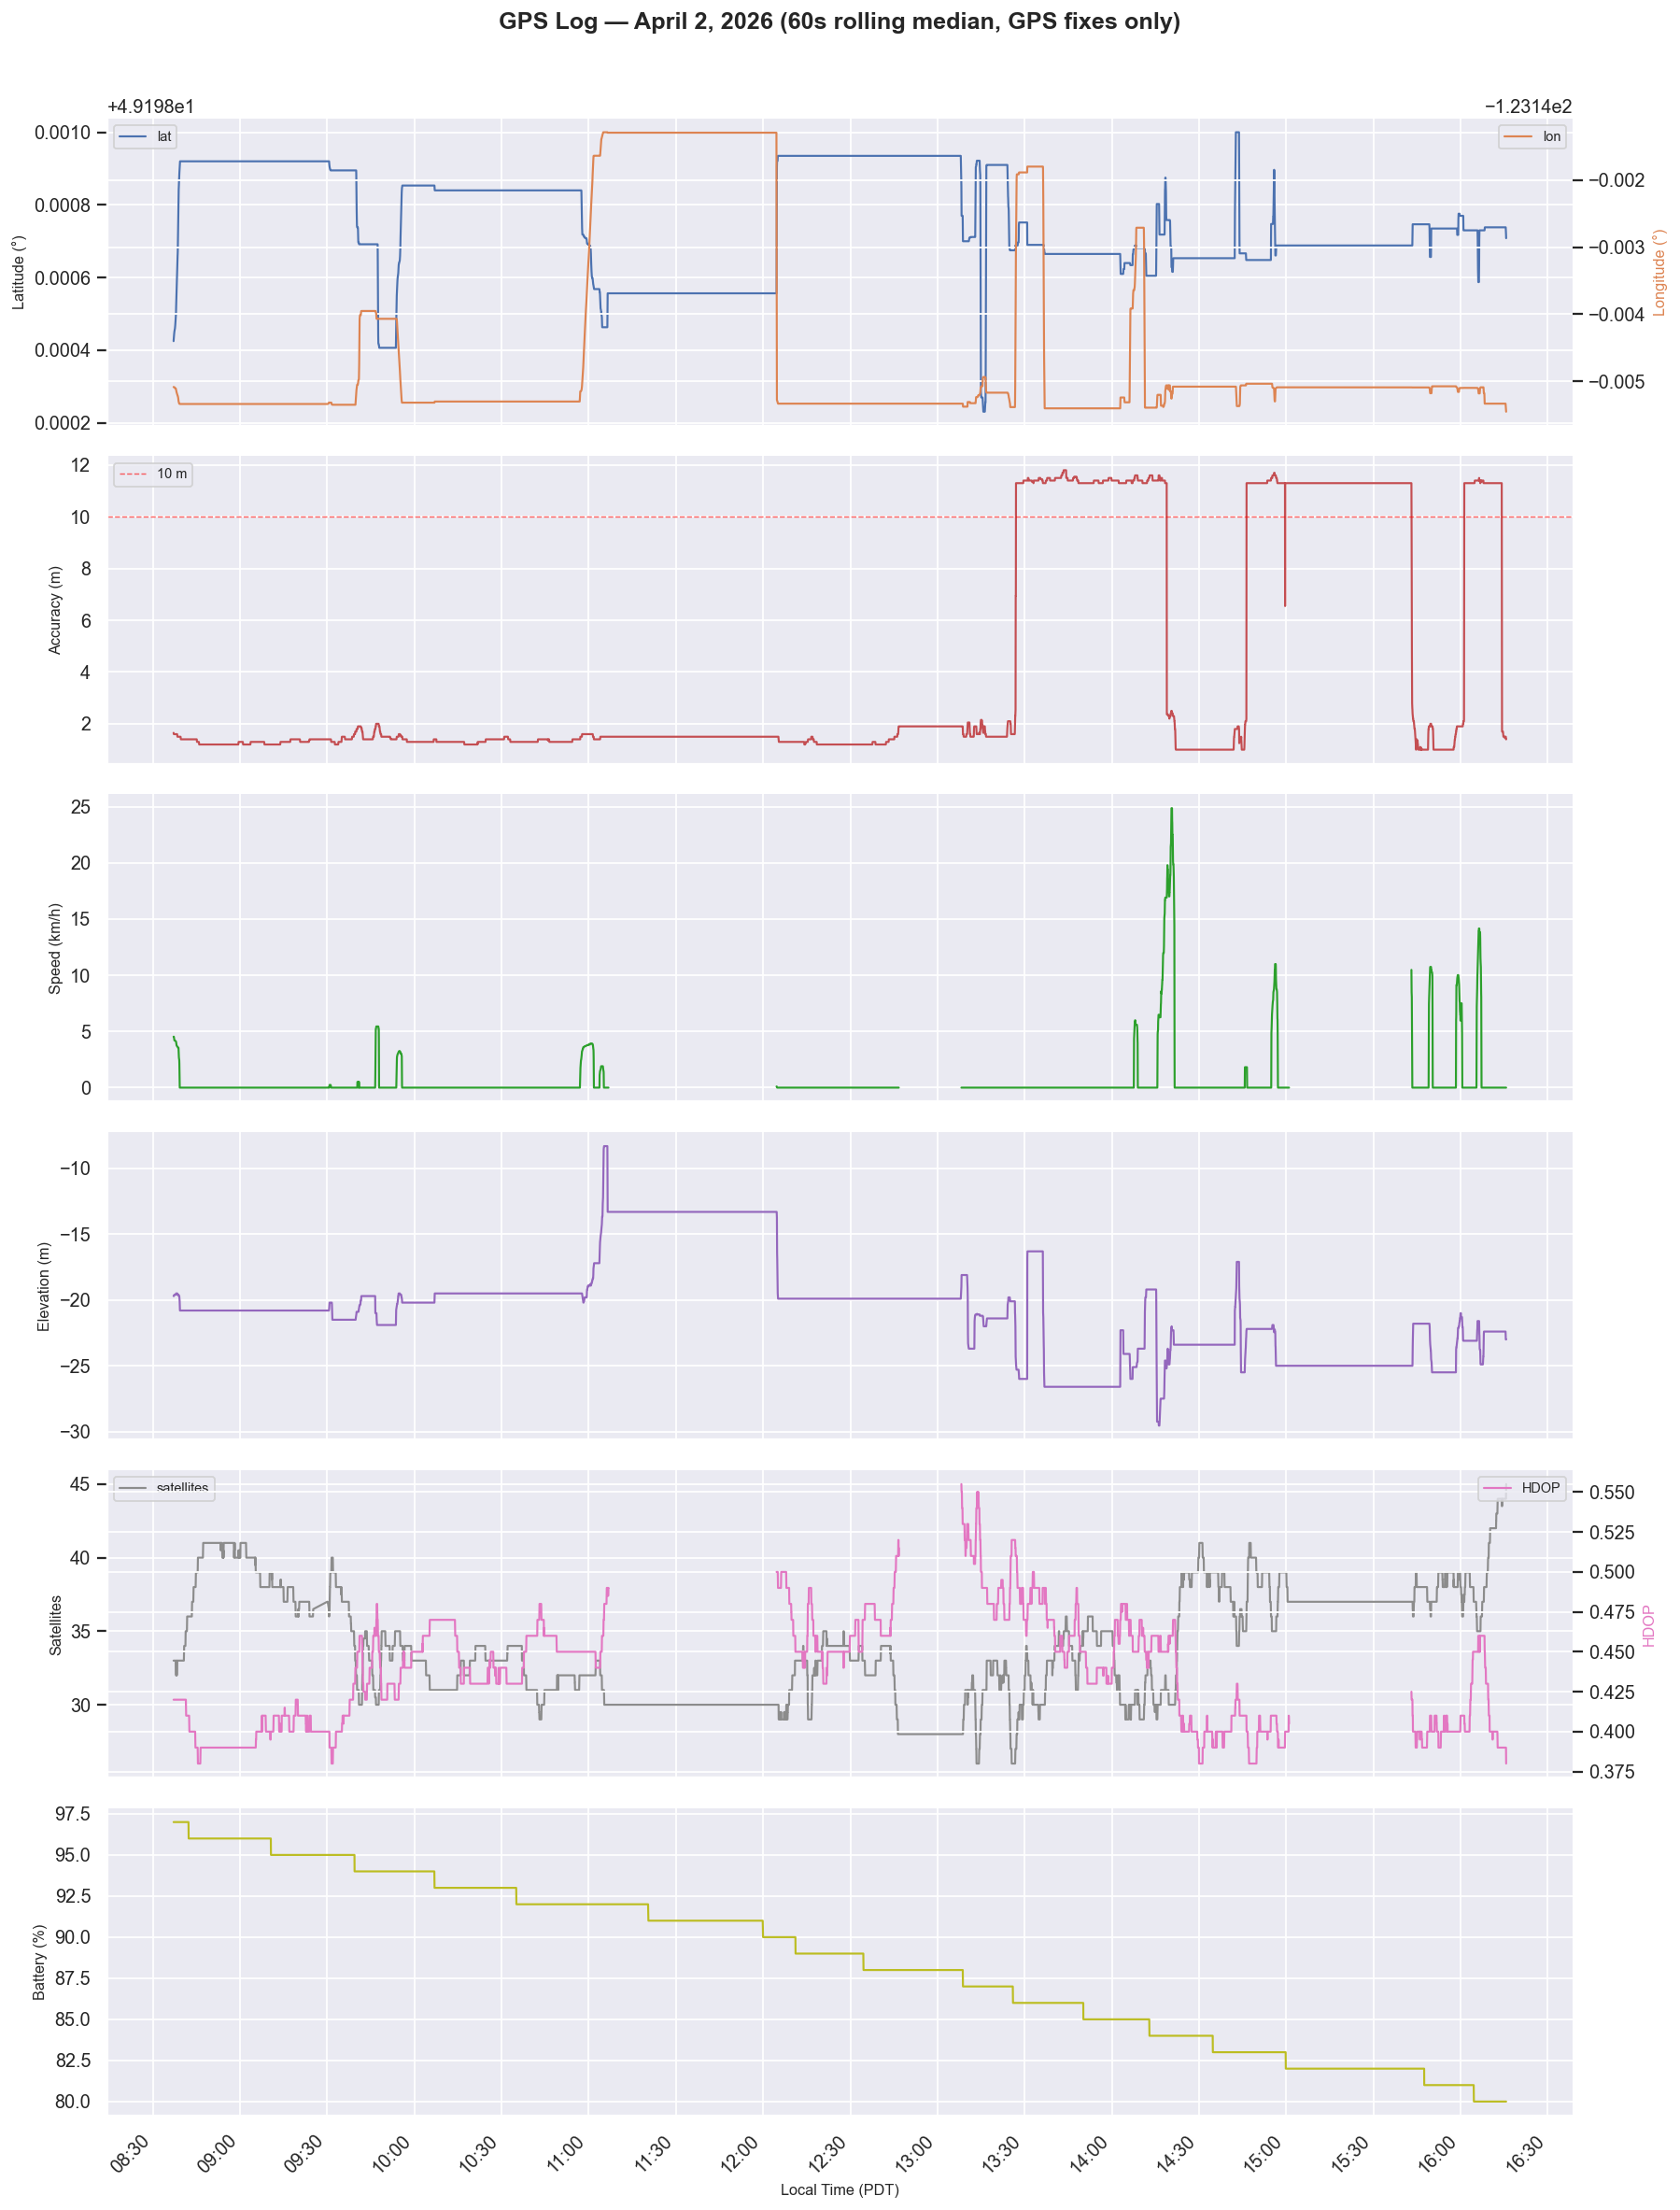

All data:      12,977 rows
GPS-only:      12,311 rows  (94.9%)
Dropped:       666 network fixes


In [10]:
# GPS-only clean dataset -- your main working data going forward
df_gps = df[df["provider"] == "gps"].copy()

# Rolling window smoother -- 60s window, median is robust to spiky outliers
W = 60  # seconds; tweak if still too noisy or too smoothed

def roll(series, window=W):
    return series.rolling(window, center=True, min_periods=window//2).median()

fig, axes = plt.subplots(6, 1, figsize=(14, 18), sharex=True)
fig.suptitle("GPS Log — April 2, 2026 (60s rolling median, GPS fixes only)", 
             fontsize=14, fontweight="bold", y=1.01)

time_gps = df_gps.index.tz_convert("America/Vancouver")

# Lat / Lon
axes[0].plot(time_gps, roll(df_gps["lat"]), lw=1.2, color="#4C72B0", label="lat")
axes[0].set_ylabel("Latitude (°)", fontsize=9)
ax0r = axes[0].twinx()
ax0r.plot(time_gps, roll(df_gps["lon"]), lw=1.2, color="#DD8452", label="lon")
ax0r.set_ylabel("Longitude (°)", fontsize=9, color="#DD8452")
axes[0].legend(loc="upper left", fontsize=8)
ax0r.legend(loc="upper right", fontsize=8)

# Accuracy
axes[1].plot(time_gps, roll(df_gps["accuracy"]), lw=1.2, color="#c44e52")
axes[1].set_ylabel("Accuracy (m)", fontsize=9)
axes[1].axhline(10, color="red", lw=0.8, ls="--", alpha=0.6, label="10 m")
axes[1].legend(fontsize=8)

# Speed
axes[2].plot(time_gps, roll(df_gps["speed_kmh"]), lw=1.2, color="#2ca02c")
axes[2].set_ylabel("Speed (km/h)", fontsize=9)

# Elevation
axes[3].plot(time_gps, roll(df_gps["elevation"]), lw=1.2, color="#9467bd")
axes[3].set_ylabel("Elevation (m)", fontsize=9)

# Satellites + HDOP
axes[4].plot(time_gps, roll(df_gps["satellites"]), lw=1.2, color="#8c8c8c", label="satellites")
axes[4].set_ylabel("Satellites", fontsize=9)
ax4r = axes[4].twinx()
ax4r.plot(time_gps, roll(df_gps["hdop"]), lw=1.2, color="#e377c2", label="HDOP")
ax4r.set_ylabel("HDOP", fontsize=9, color="#e377c2")
axes[4].legend(loc="upper left", fontsize=8)
ax4r.legend(loc="upper right", fontsize=8)

# Battery
axes[5].plot(time_gps, df_gps["battery"], lw=1.2, color="#bcbd22")  # no smoothing, it's already slow-changing
axes[5].set_ylabel("Battery (%)", fontsize=9)

# X axis
axes[5].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz="America/Vancouver"))
axes[5].xaxis.set_major_locator(mdates.MinuteLocator(byminute=range(0, 60, 30)))
plt.setp(axes[5].xaxis.get_majorticklabels(), rotation=45, ha="right")
axes[5].set_xlabel("Local Time (PDT)", fontsize=9)

fig.tight_layout()
plt.savefig("time_domain_clean.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"All data:      {len(df):,} rows")
print(f"GPS-only:      {len(df_gps):,} rows  ({len(df_gps)/len(df)*100:.1f}%)")
print(f"Dropped:       {len(df) - len(df_gps):,} network fixes")

In [13]:
import pytz

pdt = pytz.timezone("America/Vancouver")

def pdt_to_utc(date_str, time_str):
    """Parse a PDT datetime string and return UTC Timestamp."""
    dt = pd.Timestamp(f"{date_str} {time_str}").tz_localize(pdt)
    return dt.tz_convert("UTC")

# Segment definitions: (name, start_PDT, end_PDT)
# Where timestamps were missing, we use the surrounding ones with a buffer
segments = [
    ("Setup & Prep",          "08:02:00", "09:39:00"),
    ("First Driving + Faults","09:39:00", "10:00:00"),
    ("Stationary Debugging",  "10:00:00", "10:57:00"),
    ("Charging Run",          "10:57:00", "11:25:00"),
    ("FW Flash + Wait",       "11:25:00", "12:46:00"),
    ("Michael Driving",       "12:46:00", "13:15:00"),  # 12:48 small lap done, 12:53 larger loop, coast down setup ~13:05 -- buffer to 13:15
    ("Coast Down Tests",      "13:15:00", "14:05:00"),  # 13:15 lineup, 13:26:44 long coast down, second run, buffer to 14:05
    ("Multi-Driver Lapping",  "14:05:00", "16:08:00"),  # Aum ~14:05 through Luke done ~16:08
]

date = "2026-04-02"

def label_segment(row_time):
    for name, start, end in segments:
        s = pdt_to_utc(date, start)
        e = pdt_to_utc(date, end)
        if s <= row_time < e:
            return name
    return "Unassigned"

df_gps["segment"] = df_gps.index.map(label_segment)

# Summary
print(f"{'Segment':<25} {'Start (PDT)':<12} {'End (PDT)':<12} {'Rows':>6}  {'Duration'}")
print("-" * 75)
for name, start, end in segments:
    mask = df_gps["segment"] == name
    n = mask.sum()
    print(f"{name:<25} {start:<12} {end:<12} {n:>6}")

unassigned = (df_gps["segment"] == "Unassigned").sum()
print(f"\nUnassigned rows: {unassigned}")

Segment                   Start (PDT)  End (PDT)      Rows  Duration
---------------------------------------------------------------------------
Setup & Prep              08:02:00     09:39:00       2954
First Driving + Faults    09:39:00     10:00:00        531
Stationary Debugging      10:00:00     10:57:00        592
Charging Run              10:57:00     11:25:00       1041
FW Flash + Wait           11:25:00     12:46:00       2315
Michael Driving           12:46:00     13:15:00       1085
Coast Down Tests          13:15:00     14:05:00       1330
Multi-Driver Lapping      14:05:00     16:08:00       1343

Unassigned rows: 1120


In [20]:
import folium
import branca.colormap as cm
from branca.element import Template, MacroElement

# ── Driver segments ──────────────────────────────────────────────────────────
date = "2026-04-02"

driving_segments = {
    "First Driving + Faults": ("09:39:00", "10:00:00"),
    "Michael Driving":        ("12:46:00", "13:15:00"),
    "Coast Down Tests":       ("13:15:00", "14:05:00"),
}

driver_lapping = {
    "Aum":     ("14:05:00", "14:21:00"),
    "Jonah":   ("14:21:00", "14:47:00"),
    "Deev":    ("14:47:00", "14:57:00"),
    "Robin":   ("14:57:00", "15:07:00"),
    "Katrina": ("15:07:00", "15:12:00"),
    "Jay":     ("15:12:00", "15:23:00"),
    "Museok":  ("15:23:00", "15:37:00"),
    "Mueez":   ("15:37:00", "15:41:00"),
    "Chris K": ("15:41:00", "15:50:00"),
    "Krish":   ("15:50:00", "16:00:00"),
    "Hemat":   ("16:00:00", "16:04:00"),
    "Luke":    ("16:04:00", "16:08:00"),
}

def pdt_to_utc(time_str):
    return pd.Timestamp(f"{date} {time_str}").tz_localize("America/Vancouver").tz_convert("UTC")

def get_slice(start_str, end_str):
    return df_gps.loc[pdt_to_utc(start_str):pdt_to_utc(end_str)]

# ── Shared speed colormap ────────────────────────────────────────────────────
all_driving = pd.concat(
    [get_slice(s, e) for s, e in driving_segments.values()] +
    [get_slice(s, e) for s, e in driver_lapping.values()]
)
vmin, vmax = 0, all_driving["speed_kmh"].quantile(0.98)
colormap = cm.LinearColormap(
    ["#2b83ba", "#abdda4", "#ffffbf", "#fdae61", "#d7191c"],
    vmin=vmin, vmax=vmax,
    caption="Speed (km/h)"
)

vmin_day, vmax_day = 0, df_gps["speed_kmh"].quantile(0.98)
colormap_day = cm.LinearColormap(
    ["#2b83ba", "#abdda4", "#ffffbf", "#fdae61", "#d7191c"],
    vmin=vmin_day, vmax=vmax_day,
    caption="Speed (km/h)"
)

# ── Corner label macro (for non-lapping maps) ────────────────────────────────
def make_title_macro(title):
    template = f"""
    {{% macro html(this, kwargs) %}}
    <div style="position:fixed;top:12px;right:12px;z-index:9999;
                background:rgba(30,30,30,0.85);color:white;
                padding:6px 12px;border-radius:5px;
                font-size:13px;font-weight:bold;font-family:sans-serif;">
        {title}
    </div>
    {{% endmacro %}}
    """
    macro = MacroElement()
    macro._template = Template(template)
    return macro

# ── Helper: draw track with per-segment hover tooltips ───────────────────────
def add_track(fmap, df_slice, cmap, label=None):
    if df_slice.empty:
        return
    df_plot = df_slice.iloc[::2].dropna(subset=["lat", "lon", "speed_kmh"])
    if df_plot.empty:
        print(f"  Warning: no plottable points for '{label}', skipping")
        return
    for i in range(len(df_plot) - 1):
        row = df_plot.iloc[i]
        next_row = df_plot.iloc[i + 1]
        tooltip = f"{label} — {row['speed_kmh']:.1f} km/h" if label else f"{row['speed_kmh']:.1f} km/h"
        folium.PolyLine(
            locations=[[row["lat"], row["lon"]], [next_row["lat"], next_row["lon"]]],
            color=cmap(row["speed_kmh"]),
            weight=4,
            opacity=0.85,
            tooltip=tooltip,
        ).add_to(fmap)

def make_map(df_slice):
    center = [df_slice["lat"].mean(), df_slice["lon"].mean()]
    m = folium.Map(
        location=center,
        zoom_start=17,
        max_zoom=22,
        tiles=None,  # we add the tile layer manually below for max_zoom support
    )
    folium.TileLayer(
        tiles="https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}",
        attr="Google Satellite",
        name="Google Satellite",
        max_zoom=22,
        max_native_zoom=21,
    ).add_to(m)
    return m

output_dir = Path("../results/maps")
output_dir.mkdir(parents=True, exist_ok=True)

# ── Per-session maps ─────────────────────────────────────────────────────────
for name, (start, end) in driving_segments.items():
    df_slice = get_slice(start, end)
    m = make_map(df_slice)
    add_track(m, df_slice, colormap, label=name)
    m.add_child(make_title_macro(name))
    colormap.add_to(m)
    fname = output_dir / f"{name.lower().replace(' ', '_').replace('+', 'and')}.html"
    m.save(fname)
    print(f"Saved: {fname}  ({len(df_slice)} pts)")

# ── Multi-driver lapping map ─────────────────────────────────────────────────
all_lapping = pd.concat([get_slice(s, e) for s, e in driver_lapping.values()])
m_lap = make_map(all_lapping)
for driver, (start, end) in driver_lapping.items():
    add_track(m_lap, get_slice(start, end), colormap, label=driver)
m_lap.add_child(make_title_macro("Multi-Driver Lapping"))
colormap.add_to(m_lap)
m_lap.save(output_dir / "multi_driver_lapping.html")
print(f"Saved: multi_driver_lapping.html  ({len(all_lapping)} pts)")

# ── Full day map ─────────────────────────────────────────────────────────────
m_day = make_map(df_gps)
add_track(m_day, df_gps, colormap_day)
m_day.add_child(make_title_macro("Full Day"))
colormap_day.add_to(m_day)
m_day.save(output_dir / "full_day.html")
print(f"Saved: full_day.html  ({len(df_gps)} pts)")

Saved: ..\results\maps\first_driving_and_faults.html  (683 pts)
Saved: ..\results\maps\michael_driving.html  (359 pts)
Saved: ..\results\maps\coast_down_tests.html  (1885 pts)
Saved: multi_driver_lapping.html  (3203 pts)
Saved: full_day.html  (12311 pts)
